In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load and prepare data
data = pd.read_csv('Crop_recommendation.csv')
x = data.drop(['label'], axis=1)


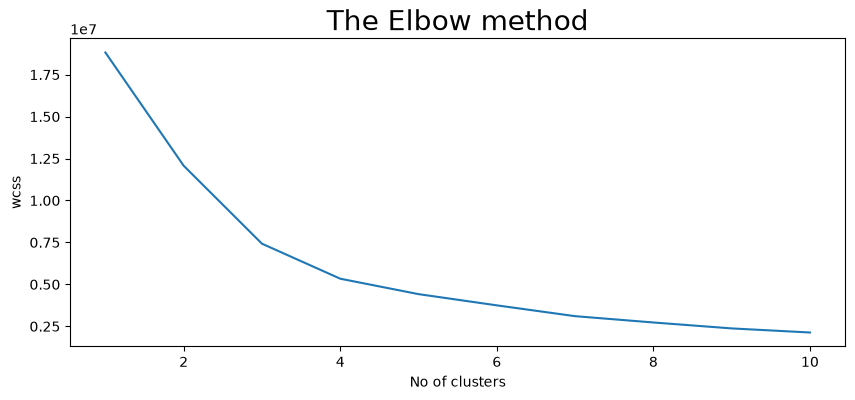

In [2]:
#el-bow method used to find out no of clusters and detemine the optimum number of clusters within the dataset.
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=(10,4)
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i,init="k-means++",max_iter=300,n_init=10,random_state=0)
    km.fit(x)
    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss)
plt.title("The Elbow method",fontsize=20)
plt.xlabel("No of clusters")
plt.ylabel("wcss")
plt.show()

In [3]:
km=KMeans(n_clusters=4,init="k-means++",max_iter=300,n_init=10,random_state=0)
y_means=km.fit_predict(x)

a=data['label']
y_means=pd.DataFrame(y_means)
z=pd.concat([y_means,a],axis=1)
z=z.rename(columns={0:'cluster'})

print("lets check the results after applying the K-Means clustering analysis \n")
print("Crops in First cluster:",z[z['cluster']==0]['label'].unique())
print("_________________________________________________________________")

print("Crops in Second cluster:",z[z['cluster']==1]['label'].unique())

print("_________________________________________________________________")

print("Crops in Third cluster:",z[z['cluster']==2]['label'].unique())

print("_________________________________________________________________")

print("Crops in Fourth cluster:",z[z['cluster']==3]['label'].unique())


lets check the results after applying the K-Means clustering analysis 

Crops in First cluster: ['grapes' 'apple']
_________________________________________________________________
Crops in Second cluster: ['maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans' 'mungbean'
 'blackgram' 'lentil' 'pomegranate' 'mango' 'orange' 'papaya' 'coconut']
_________________________________________________________________
Crops in Third cluster: ['maize' 'banana' 'watermelon' 'muskmelon' 'papaya' 'cotton' 'coffee']
_________________________________________________________________
Crops in Fourth cluster: ['rice' 'pigeonpeas' 'papaya' 'coconut' 'jute' 'coffee']


In [4]:
# Load preprocessing data with train-test split
from sklearn.model_selection import train_test_split

# Load data
data = pd.read_csv('Crop_recommendation.csv')
y = data['label']
x = data.drop(['label'], axis=1)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)


In [5]:
# Scale the data for better convergence
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Data scaled successfully")
print("x_train_scaled shape:", x_train_scaled.shape)
print("x_test_scaled shape:", x_test_scaled.shape)


Data scaled successfully
x_train_scaled shape: (1760, 7)
x_test_scaled shape: (440, 7)


In [6]:
# LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000)
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)

print("Logistic Regression Model trained successfully")
print("Predictions shape:", y_pred.shape)


Logistic Regression Model trained successfully
Predictions shape: (440,)


In [7]:
# Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

train_accuracy = model.score(x_train_scaled, y_train)
test_accuracy = accuracy_score(y_test, y_pred)

print("Model Evaluation Results:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")


Model Evaluation Results:
Training Accuracy: 0.9750
Testing Accuracy: 0.9636
Precision: 0.9648
Recall: 0.9636
F1-Score: 0.9635


In [8]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_pred)
print(cr)


              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        18
   blackgram       0.87      0.91      0.89        22
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        17
      cotton       0.94      1.00      0.97        16
      grapes       1.00      1.00      1.00        18
        jute       0.87      0.95      0.91        21
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.82      0.82      0.82        17
       maize       1.00      0.94      0.97        18
       mango       1.00      1.00      1.00        21
   mothbeans       0.95      0.84      0.89        25
    mungbean       1.00      1.00      1.00        17
   muskmelon       0.96      1.00      0.98        23
      orange       1.00      1.00      1.00        23
      papaya       0.95    

In [9]:
import numpy as np

# Make prediction for a given climatic condition
# Features: [N, P, K, temperature, humidity, ph, rainfall]
input_features = np.array([[105,35,40,25,64,7,160]])

# Scale the input using the same scaler used for training
input_scaled = scaler.transform(input_features)

# Make prediction
prediction = model.predict(input_scaled)

print("The suggested crop for given climatic condition is: ", prediction)


The suggested crop for given climatic condition is:  ['coffee']


C:\Users\YSRED\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [10]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))


In [ ]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
